In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../dataset.csv')

In [3]:
#basic cleaning
df['Gender'] = df['Gender'].str.upper().str.strip()
df['CLASS'] = df['CLASS'].astype(str).str.strip()


In [5]:
# 1. Basic Info (non-null counts and memory usage)
print("--- Dataset Info ---")
df.info()

# 2. Shape (Rows and Columns)
print(f"\n--- Dimensions ---")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# 3. Check for Missing Values
print(f"\n--- Missing Values Per Column ---")
print(df.isnull().sum())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB

--- Dimensions ---
Number of Rows: 1000
Number of Columns: 14

--- Missing Values Per Column ---
ID           0
No_Pation    0
Gender       0
AGE          0
Urea       

In [ ]:
#4. Check for Unique Values (Categorical Columns)
print("\n--- Unique Categories ---")
print(f"Gender: {df['Gender'].unique()}")
print(f"CLASS: {df['CLASS'].unique()}")


--- Unique Categories ---
Gender: ['F' 'M']
CLASS: ['N' 'P' 'Y']


In [ ]:
# 6. Check for Impossible/Extreme values (Data Cleaning)
# Based on medical norms, we check for illogical values
print("\n--- Outlier/Logic Check ---")
print(f"Negative Age: {len(df[df['AGE'] < 0])}")
print(f"Zero Urea/Cr: {len(df[(df['Urea'] <= 0) | (df['Cr'] <= 0)])}")



--- Outlier/Logic Check ---
Negative Age: 0
Zero Urea/Cr: 0


In [7]:
summary = df.describe()
# Round the entire summary DataFrame to 2 decimal places
rounded_summary = summary.round(2)
# Display the result
print(rounded_summary)

            ID    No_Pation      AGE     Urea       Cr    HbA1c     Chol  \
count  1000.00      1000.00  1000.00  1000.00  1000.00  1000.00  1000.00   
mean    340.50    270551.41    53.53     5.12    68.94     8.28     4.86   
std     240.40   3380757.82     8.80     2.94    59.98     2.53     1.30   
min       1.00       123.00    20.00     0.50     6.00     0.90     0.00   
25%     125.75     24063.75    51.00     3.70    48.00     6.50     4.00   
50%     300.50     34395.50    55.00     4.60    60.00     8.00     4.80   
75%     550.25     45384.25    59.00     5.70    73.00    10.20     5.60   
max     800.00  75435657.00    79.00    38.90   800.00    16.00    10.30   

            TG      HDL      LDL     VLDL      BMI  
count  1000.00  1000.00  1000.00  1000.00  1000.00  
mean      2.35     1.20     2.61     1.85    29.58  
std       1.40     0.66     1.12     3.66     4.96  
min       0.30     0.20     0.30     0.10    19.00  
25%       1.50     0.90     1.80     0.70    26.00

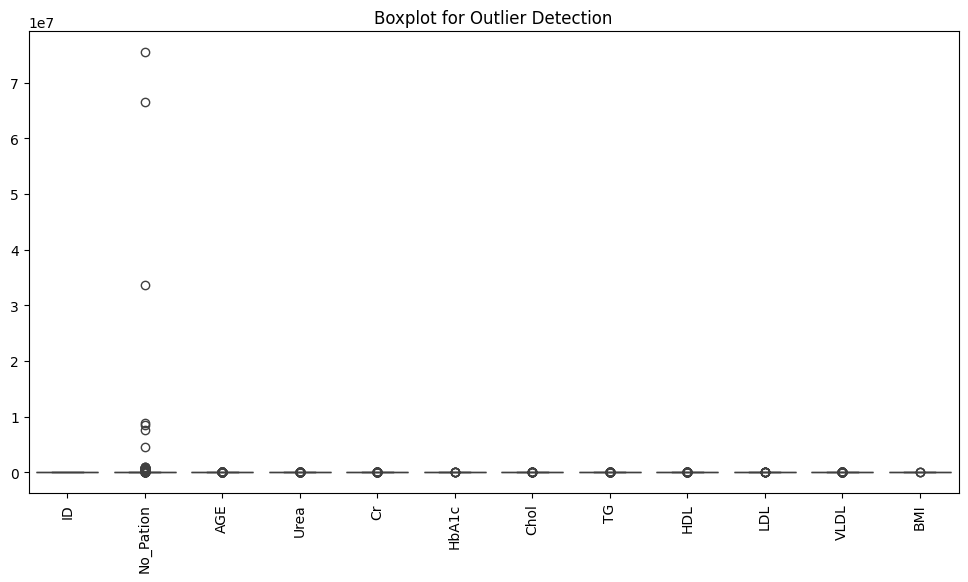

In [ ]:
# 7. Visual Check for Outliers (Using Boxplots)
# If a value is 5-10x the mean, it's often a data entry error
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [9]:
numeric_cols = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
print("\n--- Mean Values by Class ---")
print(df.groupby('CLASS')[numeric_cols].mean())


--- Mean Values by Class ---
             AGE      Urea         Cr     HbA1c      Chol        TG       HDL  \
CLASS                                                                           
N      44.233010  4.680583  62.796117  4.560194  4.268932  1.625243  1.227184   
P      43.283019  4.511321  66.075472  6.003774  4.579245  2.126415  1.127358   
Y      55.305687  5.217468  69.873223  8.878270  4.953104  2.452026  1.206872   

            LDL      VLDL        BMI  
CLASS                                 
N      2.625243  0.943689  22.374757  
P      2.493396  0.983019  23.933962  
Y      2.615213  2.020616  30.811517  


C:\Users\Hams\AppData\Local\Temp\ipykernel_44584\3004918053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CLASS', data=df, ax=axes[0], palette='viridis')


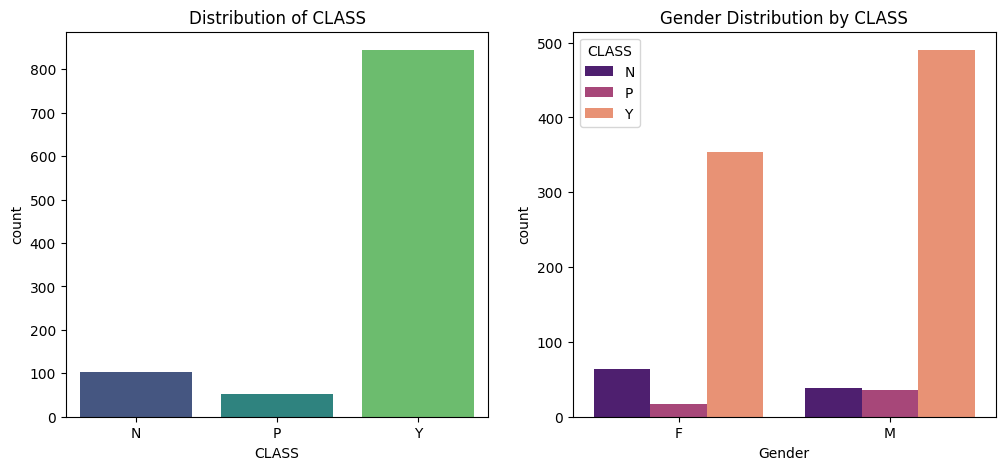

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='CLASS', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of CLASS')
sns.countplot(x='Gender', hue='CLASS', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Gender Distribution by CLASS')
plt.show()

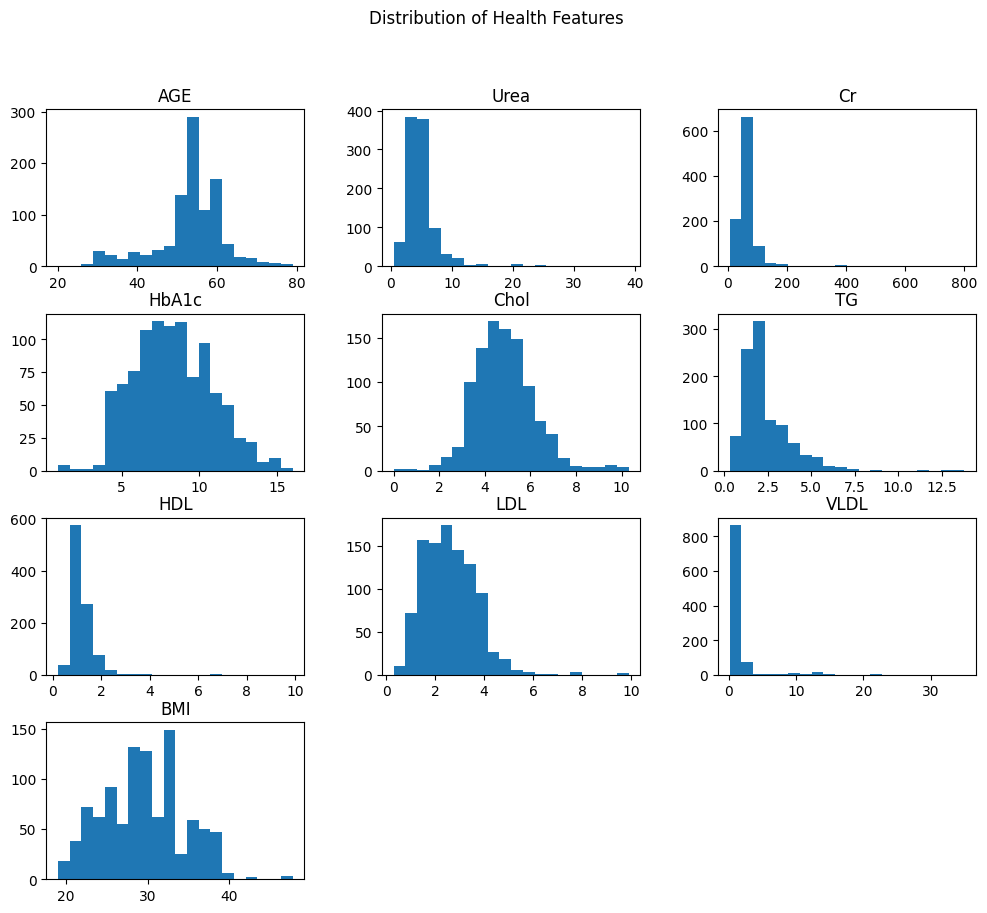

In [12]:
# --- 5. Feature Distributions ---
df[numeric_cols].hist(figsize=(12, 10), bins=20, grid=False)
plt.suptitle('Distribution of Health Features')
plt.show()

In [ ]:
# In medical data, "extreme" often means "highest clinical importance." Removing those patients would be discarding the most critical data points.
#  Instead, we can use robust scaling or log transformations to handle skewness without losing valuable information.
# Apply log1p (log(1+x)) to handle skewed medical features
# This preserves the 'extremeness' of the high-value patients
# in normal cases, we would consider removing them as outliers, but in medical datasets, those outliers often represent the most critical cases that we want to predict accurately.
skewed_cols = ['Urea', 'Cr', 'TG', 'VLDL']
for col in skewed_cols:
    df[col] = np.log1p(df[col])

print("Log transformation applied to skewed features.")
print(df[skewed_cols].describe().round(2))


Log transformation applied to skewed features.
          Urea       Cr       TG     VLDL
count  1000.00  1000.00  1000.00  1000.00
mean      1.00     1.63     0.75     0.56
std       0.13     0.08     0.17     0.23
min       0.34     1.08     0.23     0.09
25%       0.94     1.59     0.65     0.43
50%       1.00     1.63     0.74     0.50
75%       1.07     1.67     0.86     0.65
max       1.54     2.04     1.31     1.52


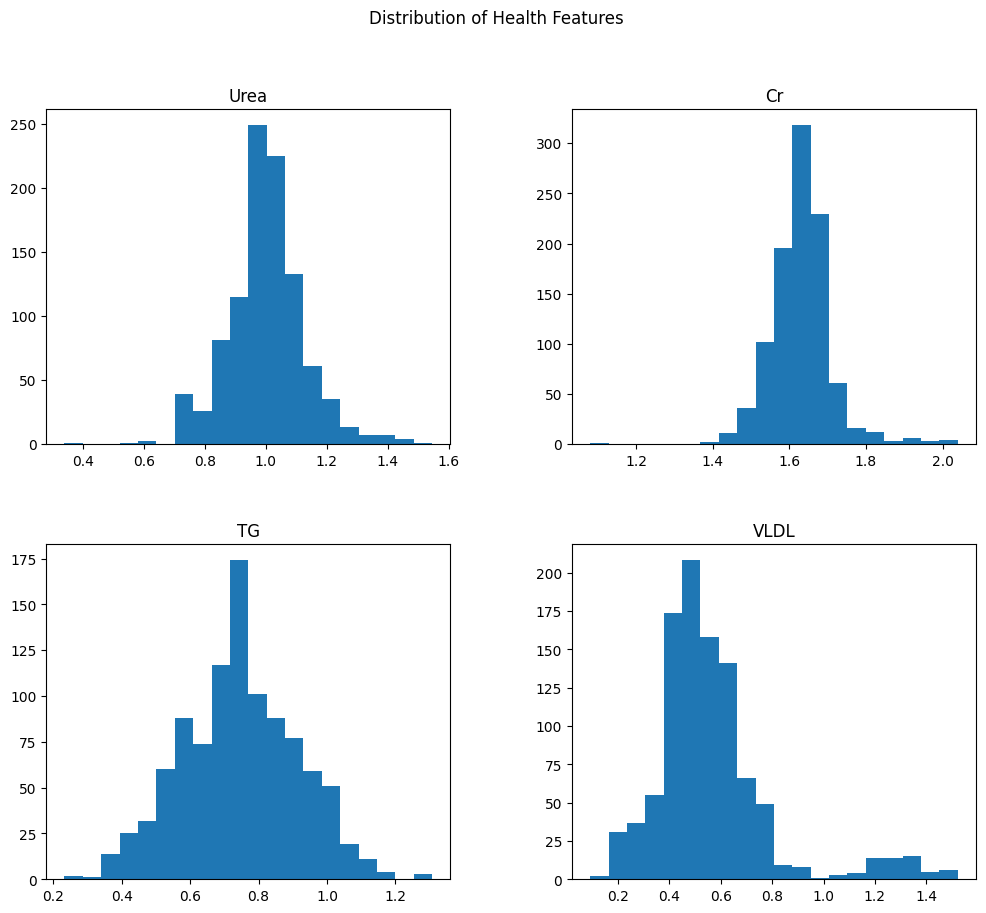

In [18]:
df[skewed_cols].hist(figsize=(12, 10), bins=20, grid=False)
plt.suptitle('Distribution of Health Features')
plt.show()

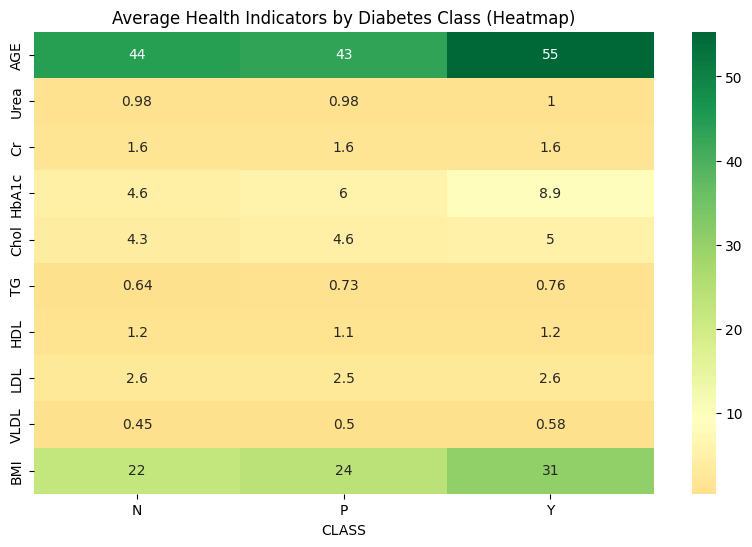

In [19]:
# how the class (Diabetic vs. Non-Diabetic) relates to the averages of key variables
# Select key medical indicators
medical_indicators = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

# Create a custom heatmap of mean differences
plt.figure(figsize=(10, 6))
class_means = df.groupby('CLASS')[medical_indicators].mean()
sns.heatmap(class_means.T, annot=True, cmap='RdYlGn', center=class_means.mean().mean())
plt.title('Average Health Indicators by Diabetes Class (Heatmap)')
plt.show()

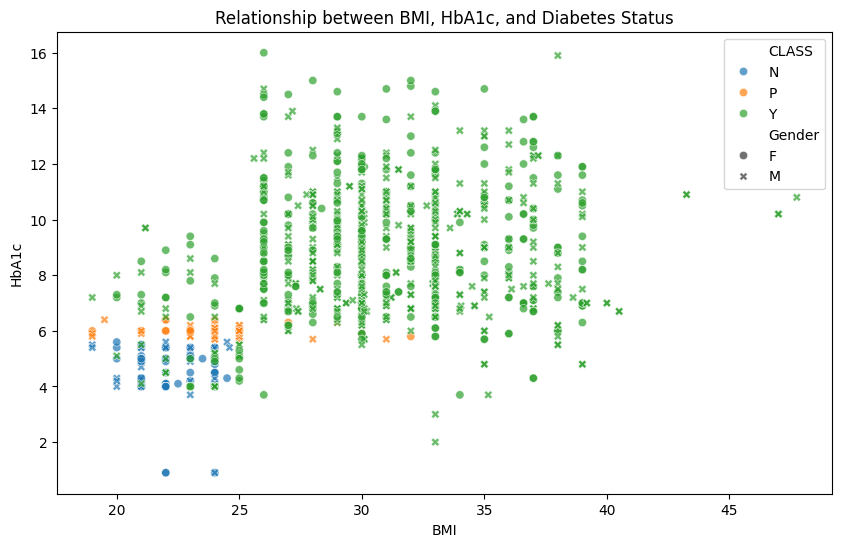

In [20]:
# Explore the relationship between BMI, HbA1c, and CLASS (Diabetes Status)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='HbA1c', hue='CLASS', data=df, style='Gender', alpha=0.7)
plt.title('Relationship between BMI, HbA1c, and Diabetes Status')
plt.show()

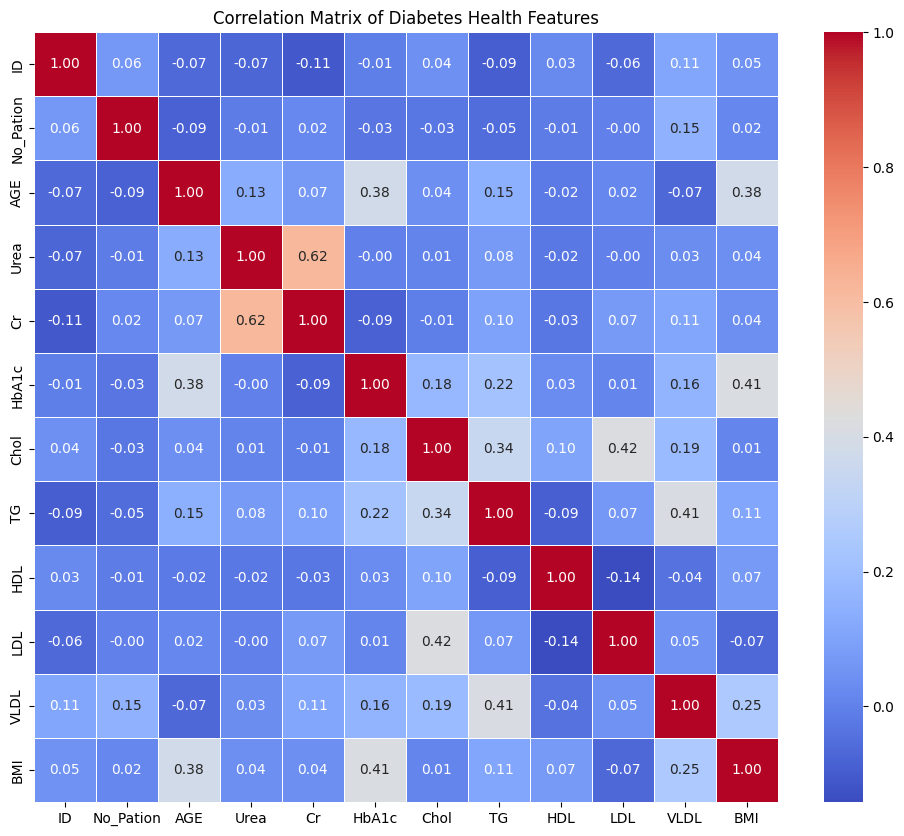

In [21]:
# Select only numerical columns for correlation
numerical_data = df.select_dtypes(include=[np.number])

# Generate Correlation Matrix
corr_matrix = numerical_data.corr()

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Diabetes Health Features')
plt.show()

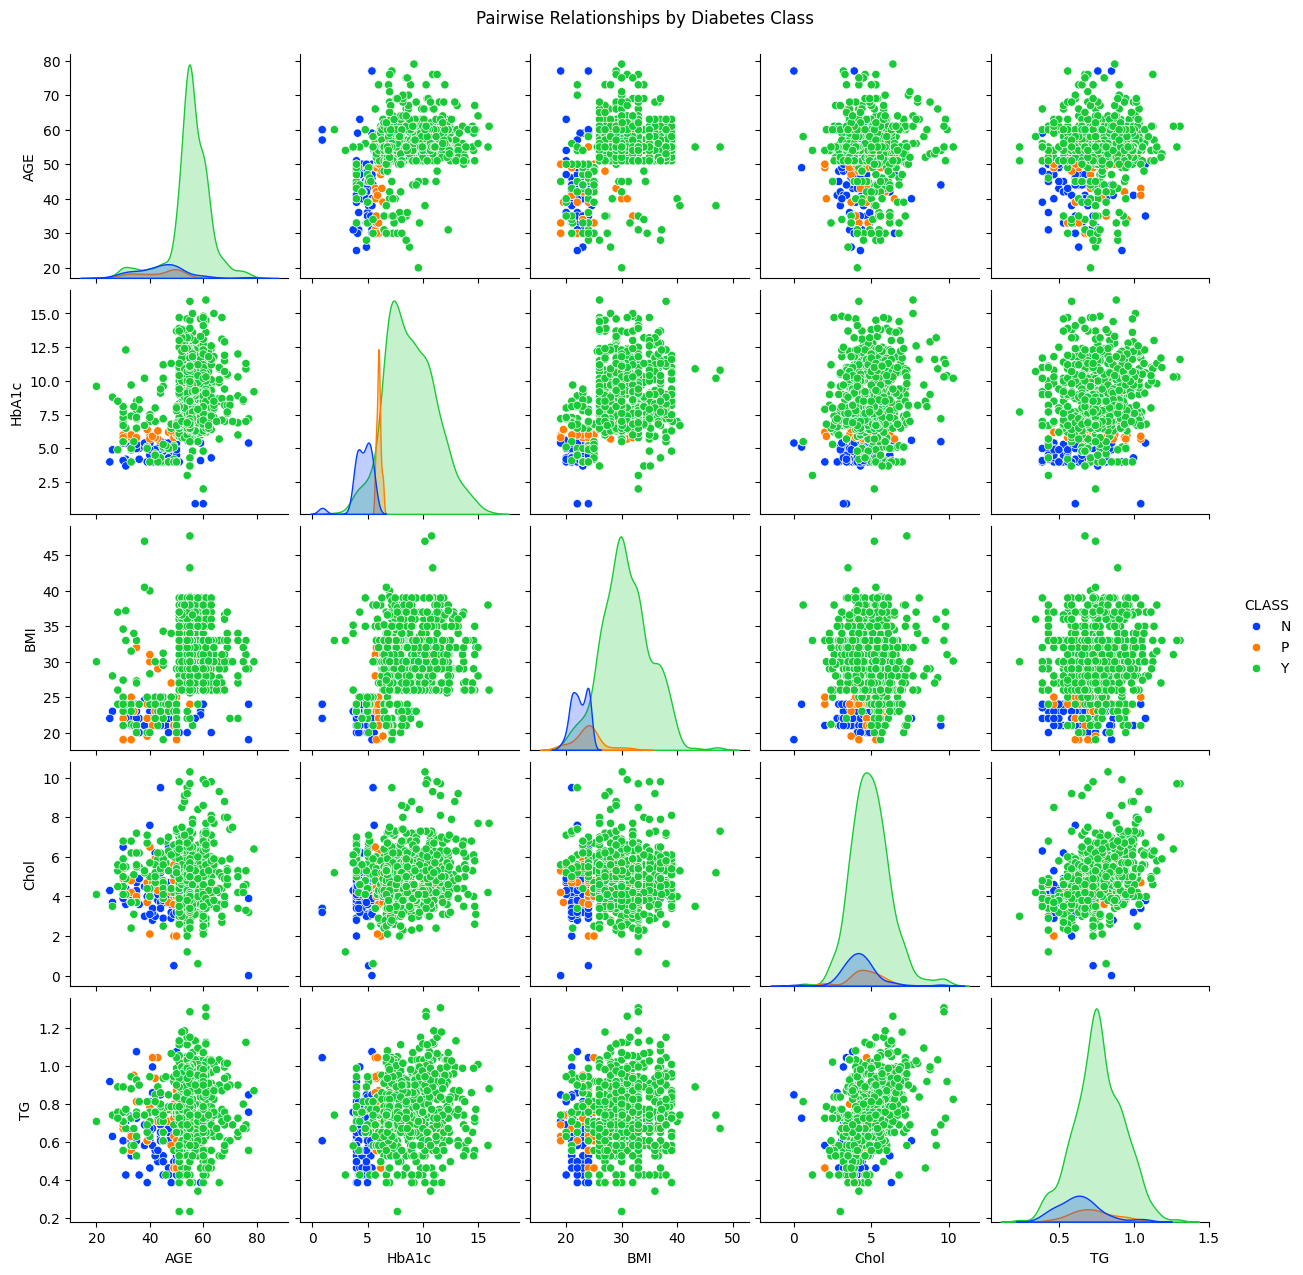

In [22]:
# Pairwise relationships between key features, colored by CLASS
# Choose a subset to keep the plot readable
features_to_plot = ['AGE', 'HbA1c', 'BMI', 'Chol', 'TG', 'CLASS']

# Pairplot
sns.pairplot(df[features_to_plot], hue='CLASS', palette='bright', diag_kind='kde')
plt.suptitle('Pairwise Relationships by Diabetes Class', y=1.02)
plt.show()

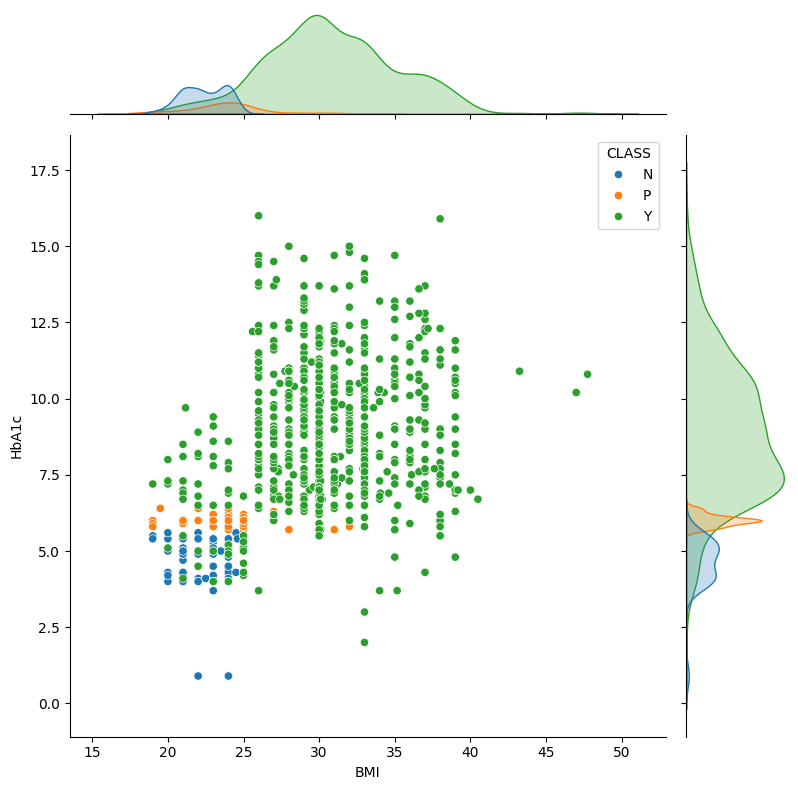

In [24]:
# Jointplot to see the correlation and distribution together
sns.jointplot(x='BMI', y='HbA1c', data=df, hue='CLASS', kind='scatter', height=8)
plt.show()